In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

plt.rcParams["font.family"] = "serif"

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [3]:
df = pd.read_csv("../results/benchmark_batched_gemv.csv")
df["times (ms)"] = df["times (ms)"].apply(ast.literal_eval)
df["time (ms)"] = df["times (ms)"].apply(min)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms)
0,44369,55,float32,float32,irrespective,"[1.072966079711914, 1.0736358642578125, 1.0744...",1.551609e-03,1.072966
1,44369,55,float32,float32,synchronized,"[1.018199691772461, 1.018112335205078, 1.01798...",1.551609e-03,1.016978
2,44369,55,float16,float32,irrespective,"[0.5559318542480469, 0.5558367919921875, 0.556...",1.552413e-03,0.555821
3,44369,55,float16,float32,synchronized,"[0.5314188766479492, 0.5313363265991211, 0.531...",1.552413e-03,0.531336
4,44369,55,bfloat16,float32,irrespective,"[0.5556982421875, 0.5556547164916992, 0.555720...",1.549436e-03,0.555537
...,...,...,...,...,...,...,...,...
191,29026,68,float64,float64,synchronized,"[2.0394960021972657, 2.0393402099609377, 2.039...",3.635289e-12,2.039087
192,29026,68,float16,float64,irrespective,"[1.0461500549316407, 1.046146240234375, 1.0461...",3.640093e-12,1.046097
193,29026,68,float16,float64,synchronized,"[1.1515302276611328, 1.1515090942382813, 1.151...",3.640093e-12,1.151498
194,29026,68,bfloat16,float64,irrespective,"[1.0483535766601562, 1.0483225250244141, 1.048...",3.643316e-12,1.048318


In [4]:
def throughput(n, k, time_ms, mat_dtype, vec_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [5]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [6]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"],
        k=row["k"],
        time_ms=row["time (ms)"],
        mat_dtype=row["A_dtype"],
        vec_dtype=row["b_dtype"],
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms),throughput,GFlops
0,44369,55,float32,float32,irrespective,"[1.072966079711914, 1.0736358642578125, 1.0744...",1.551609e-03,1.072966,518.550652,250.177946
1,44369,55,float32,float32,synchronized,"[1.018199691772461, 1.018112335205078, 1.01798...",1.551609e-03,1.016978,547.098498,263.951030
2,44369,55,float16,float32,irrespective,"[0.5559318542480469, 0.5558367919921875, 0.556...",1.552413e-03,0.555821,518.071018,482.947559
3,44369,55,float16,float32,synchronized,"[0.5314188766479492, 0.5313363265991211, 0.531...",1.552413e-03,0.531336,541.944519,505.202518
4,44369,55,bfloat16,float32,irrespective,"[0.5556982421875, 0.5556547164916992, 0.555720...",1.549436e-03,0.555537,518.335726,483.194321
...,...,...,...,...,...,...,...,...,...,...
191,29026,68,float64,float64,synchronized,"[2.0394960021972657, 2.0393402099609377, 2.039...",3.635289e-12,2.039087,542.061248,131.643446
192,29026,68,float16,float64,irrespective,"[1.0461500549316407, 1.046146240234375, 1.0461...",3.640093e-12,1.046097,286.792393,256.603720
193,29026,68,float16,float64,synchronized,"[1.1515302276611328, 1.1515090942382813, 1.151...",3.640093e-12,1.151498,260.541267,233.115870
194,29026,68,bfloat16,float64,irrespective,"[1.0483535766601562, 1.0483225250244141, 1.048...",3.643316e-12,1.048318,286.184912,256.060185


In [15]:
def plot_throughput(ax, mat_dtype: str, vec_dtype: str, labels: bool = False):
    max_tput = df[
        (df.A_dtype == mat_dtype) & (df.b_dtype == vec_dtype) & (df.k <= 128)
    ].pivot_table(values="throughput", columns="algorithm", index="k", aggfunc="max")

    title = f"{mat_dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=130)
    ax.set_ylim(bottom=0, top=2140)

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    algorithms = df["algorithm"].unique()
    marker = {"irrespective": "s", "synchronized": "^", "torch": "o"}
    color = {"irrespective": "tab:blue", "synchronized": "tab:green", "torch": "tab:orange"}

    for alg in algorithms:
        ax.scatter(
            x=max_tput.index,
            y=max_tput[alg],
            marker=marker[alg],
            label=alg if labels else None,
            s=13,
            zorder=3,
            facecolors="none",
            edgecolors=color[alg],
        )
    ax.axhline(
        y=2039,
        color="red",
        linestyle="--",
        label="A100 bandwidth (2,039GB/s)" if labels else None,
    )

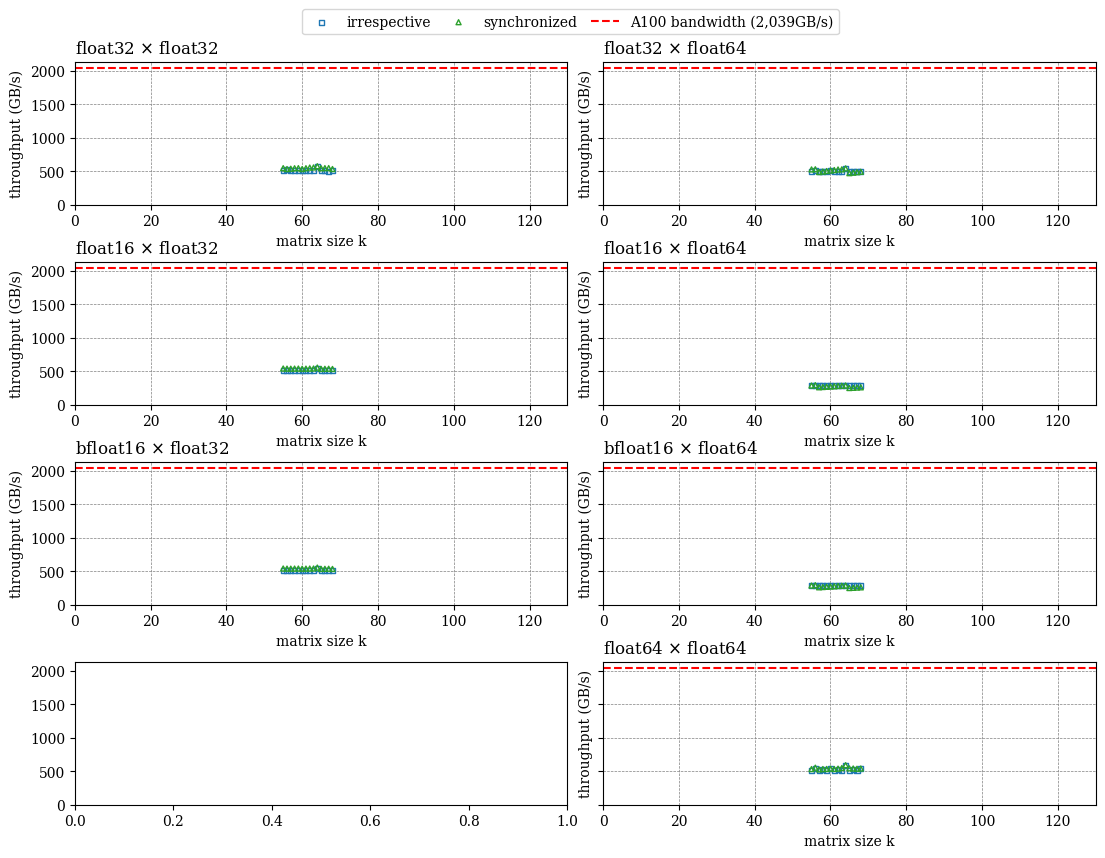

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharey=True)
fig.tight_layout(pad=1.0, h_pad=2.0)
for i, mat_dtype in enumerate(df.A_dtype.unique()):
    for j, vec_dtype in enumerate(df.b_dtype.unique()):
        if mat_dtype == "float64" and vec_dtype == "float32":
            continue
        plot_throughput(axes[i, j], mat_dtype, vec_dtype, labels=(i == 0 and j == 0))

fig.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
# fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

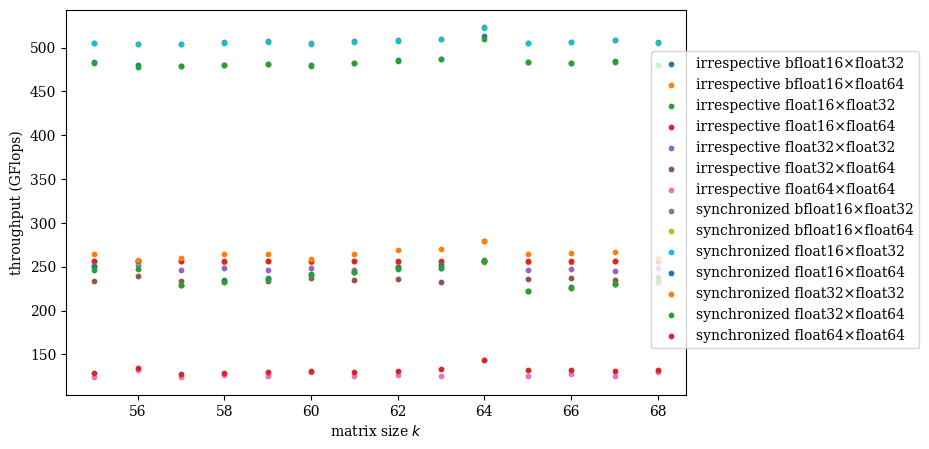

In [18]:
max_tput = df.pivot_table(
    values="GFlops",
    columns=["algorithm", "A_dtype", "b_dtype"],
    index="k",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    ax.scatter(
        max_tput.index,
        max_tput[col],
        label=col[0] + " " + col[1] + "×" + col[2],
        s=10,
    )

fig.legend(loc="right", bbox_to_anchor=(1.2, 0.5))